###A1. Importing Libraries and Loading the Dataset

In [18]:
import kagglehub
import pandas as pd
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.anova import anova_lm

# Download the latest version of the dataset
path = kagglehub.dataset_download("prokshitha/home-value-insights")

print("Path to dataset files:", path)

# List files in the downloaded folder
print("\nFiles in dataset folder:")
print(os.listdir(path))

# Find CSV files
csv_files = glob.glob(os.path.join(path, "*.csv"))

print("\nCSV files found:")
print(csv_files)

# Load the CSV file
df = pd.read_csv(csv_files[0])

# Display first 5 rows
df.head()

Using Colab cache for faster access to the 'home-value-insights' dataset.
Path to dataset files: /kaggle/input/home-value-insights

Files in dataset folder:
['house_price_regression_dataset.csv']

CSV files found:
['/kaggle/input/home-value-insights/house_price_regression_dataset.csv']


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


### A2. Data Inspection and Descriptive Statistics


In [19]:
# Dataset dimensions
print("Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Data types
print("\nData types:")
print(df.dtypes)

# Missing values
print("\nMissing values:")
print(df.isnull().sum())

# Descriptive statistics
print("\nDescriptive statistics:")
display(df.describe())

Shape: (1000, 8)

Columns:
['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price']

Data types:
Square_Footage            int64
Num_Bedrooms              int64
Num_Bathrooms             int64
Year_Built                int64
Lot_Size                float64
Garage_Size               int64
Neighborhood_Quality      int64
House_Price             float64
dtype: object

Missing values:
Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

Descriptive statistics:


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [20]:
# Select variables for the regression analysis

variables = [
    "House_Price",
    "Square_Footage",
    "Num_Bathrooms",
    "Lot_Size",
    "Neighborhood_Quality",
    "Garage_Size"
]

analysis_df = df[variables].copy()

# Check the selected data
display(analysis_df.head())

print("Missing values in selected variables:")
print(analysis_df.isnull().sum())

,House_Price,Square_Footage,Num_Bathrooms,Lot_Size,Neighborhood_Quality,Garage_Size
0,2.623829e+05,1360,1,0.599637,5,0
1,9.852609e+05,4272,3,4.753014,6,1
2,7.779774e+05,3592,2,3.634823,9,0
3,2.296989e+05,966,2,2.730667,8,1
4,1.041741e+06,4926,1,4.699073,8,0


Missing values in selected variables:
House_Price             0
Square_Footage          0
Num_Bathrooms           0
Lot_Size                0
Neighborhood_Quality    0
Garage_Size             0
dtype: int64


###correlation matrix

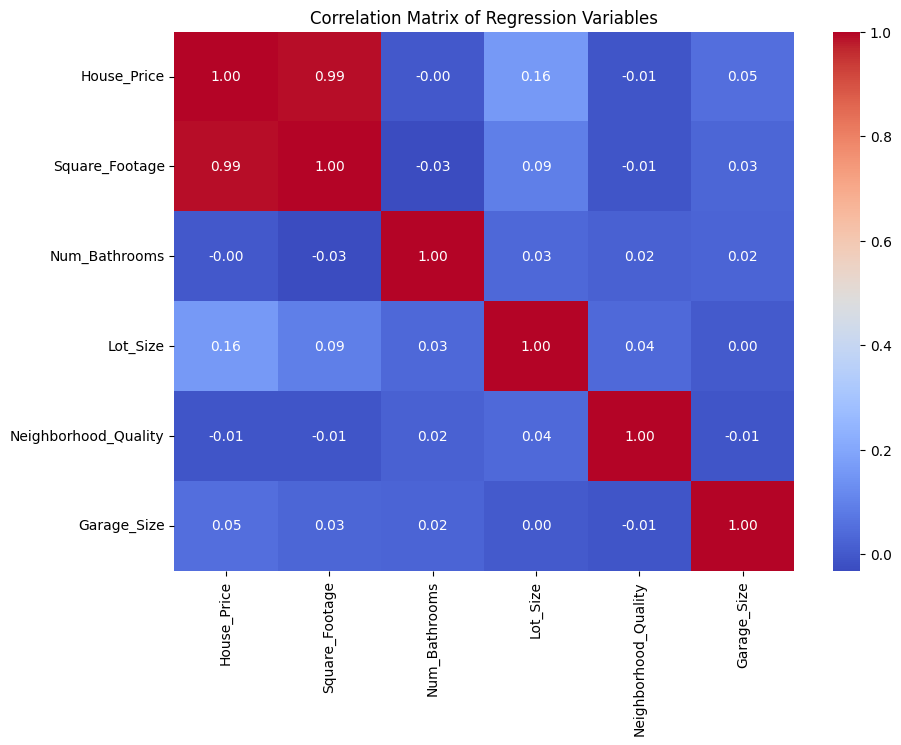

In [21]:
# Correlation matrix

corr_matrix = analysis_df.corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Regression Variables")
plt.show()

### A3. Model 1

In [22]:
# Model 1: Baseline model
# Three theoretically relevant predictors

model1 = smf.ols(
    "House_Price ~ Square_Footage + Num_Bathrooms + Neighborhood_Quality",
    data=analysis_df
).fit()

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:            House_Price   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                 1.975e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:45:32   Log-Likelihood:                -11811.
No. Observations:                1000   AIC:                         2.363e+04
Df Residuals:                     996   BIC:                         2.365e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             3.671e+04 

### A4. Model 2

In [23]:
# Model 2: Refined model
# Adds Lot_Size and Garage_Size

model2 = smf.ols(
    "House_Price ~ Square_Footage + Num_Bathrooms + Neighborhood_Quality + Lot_Size + Garage_Size",
    data=analysis_df
).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:            House_Price   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                 1.780e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:45:32   Log-Likelihood:                -11609.
No. Observations:                1000   AIC:                         2.323e+04
Df Residuals:                     994   BIC:                         2.326e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept            -1531.0072 

### Model Comparison

In [24]:
# Calculate residual standard error

residual_se_1 = np.sqrt(model1.ssr / model1.df_resid)
residual_se_2 = np.sqrt(model2.ssr / model2.df_resid)

# Create model comparison table

model_comparison = pd.DataFrame({
    "Model": ["Model 1", "Model 2"],
    "R²": [model1.rsquared, model2.rsquared],
    "Adjusted R²": [model1.rsquared_adj, model2.rsquared_adj],
    "AIC": [model1.aic, model2.aic],
    "BIC": [model1.bic, model2.bic],
    "Residual Standard Error": [residual_se_1, residual_se_2],
    "Number of Predictors": [3, 5]
})

display(model_comparison.round(4))

,Model,R²,Adjusted R²,AIC,BIC,Residual Standard Error,Number of Predictors
0,Model 1,0.9835,0.9834,23629.2448,23648.8758,32652.8643,3
1,Model 2,0.9890,0.9889,23230.0708,23259.5173,26718.3504,5


In [27]:
# Compare regression coefficients

coefficient_comparison = pd.DataFrame({
    "Model 1": model1.params,
    "Model 2": model2.params
})

display(coefficient_comparison.round(4))

,Model 1,Model 2
Garage_Size,NaN,6578.6105
Intercept,36710.9338,-1531.0072
Lot_Size,NaN,13948.2860
Neighborhood_Quality,0.3197,-214.9924
Num_Bathrooms,9110.7930,8121.1635
Square_Footage,200.3865,198.9411


In [26]:
# Compare Model 1 and Model 2 using a nested F-test

anova_results = anova_lm(model1, model2)

display(anova_results)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,996.0,1.061945e+12,0.0,NaN,NaN,NaN
1,994.0,7.095870e+11,2.0,3.523577e+11,246.793926,9.487881e-88


In [28]:
print("MODEL COMPARISON")
print("=" * 60)

print(f"Model 1 Adjusted R²: {model1.rsquared_adj:.4f}")
print(f"Model 2 Adjusted R²: {model2.rsquared_adj:.4f}")

print(f"\nModel 1 AIC: {model1.aic:.2f}")
print(f"Model 2 AIC: {model2.aic:.2f}")

print(f"\nModel 1 BIC: {model1.bic:.2f}")
print(f"Model 2 BIC: {model2.bic:.2f}")

print(f"\nModel 1 Residual SE: {residual_se_1:.2f}")
print(f"Model 2 Residual SE: {residual_se_2:.2f}")

print("\nNested model F-test:")
display(anova_results)

MODEL COMPARISON
Model 1 Adjusted R²: 0.9834
Model 2 Adjusted R²: 0.9889

Model 1 AIC: 23629.24
Model 2 AIC: 23230.07

Model 1 BIC: 23648.88
Model 2 BIC: 23259.52

Model 1 Residual SE: 32652.86
Model 2 Residual SE: 26718.35

Nested model F-test:


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,996.0,1.061945e+12,0.0,NaN,NaN,NaN
1,994.0,7.095870e+11,2.0,3.523577e+11,246.793926,9.487881e-88


In [29]:
# Select the preferred model after examining the comparison above.
# Initially, Model 2 is selected because it includes all five selected predictors.

preferred_model = model2

print(preferred_model.summary())

                            OLS Regression Results                            
Dep. Variable:            House_Price   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                 1.780e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:53:14   Log-Likelihood:                -11609.
No. Observations:                1000   AIC:                         2.323e+04
Df Residuals:                     994   BIC:                         2.326e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept            -1531.0072 

In [30]:
# Create a clean coefficient table

coef_table = pd.DataFrame({
    "Coefficient": preferred_model.params,
    "Std. Error": preferred_model.bse,
    "t-value": preferred_model.tvalues,
    "p-value": preferred_model.pvalues,
    "CI Lower": preferred_model.conf_int()[0],
    "CI Upper": preferred_model.conf_int()[1]
})

display(coef_table.round(4))

,Coefficient,Std. Error,t-value,p-value,CI Lower,CI Upper
Intercept,-1531.0072,3813.2334,-0.4015,0.6881,-9013.9190,5951.9045
Square_Footage,198.9411,0.6768,293.9478,0.0000,197.6130,200.2692
Num_Bathrooms,8121.1635,1032.2119,7.8677,0.0000,6095.5989,10146.7281
Neighborhood_Quality,-214.9924,293.0842,-0.7336,0.4634,-790.1272,360.1423
Lot_Size,13948.2860,654.8700,21.2993,0.0000,12663.1996,15233.3724
Garage_Size,6578.6105,1038.1524,6.3368,0.0000,4541.3886,8615.8324


In [31]:
# Identify statistically significant and non-significant predictors

p_values = preferred_model.pvalues.drop("Intercept")

print("Statistically significant predictors (p < 0.05):")
print(p_values[p_values < 0.05])

print("\nNon-significant predictors (p >= 0.05):")
print(p_values[p_values >= 0.05])

Statistically significant predictors (p < 0.05):
Square_Footage    0.000000e+00
Num_Bathrooms     9.389208e-15
Lot_Size          3.189677e-83
Garage_Size       3.549845e-10
dtype: float64

Non-significant predictors (p >= 0.05):
Neighborhood_Quality    0.463395
dtype: float64


In [32]:
print(f"R² = {preferred_model.rsquared:.4f}")
print(f"Adjusted R² = {preferred_model.rsquared_adj:.4f}")

print(
    f"\nThe model explains approximately "
    f"{preferred_model.rsquared * 100:.2f}% of the variation in House_Price."
)

R² = 0.9890
Adjusted R² = 0.9889

The model explains approximately 98.90% of the variation in House_Price.


### A6. Diagnostic Tests

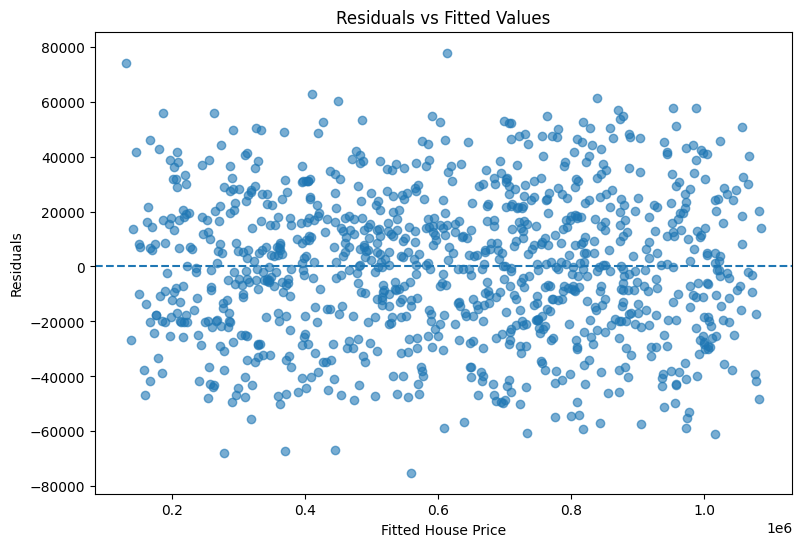

In [33]:
# Calculate fitted values and residuals

fitted = preferred_model.fittedvalues
residuals = preferred_model.resid

plt.figure(figsize=(9, 6))
plt.scatter(fitted, residuals, alpha=0.6)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Fitted House Price")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

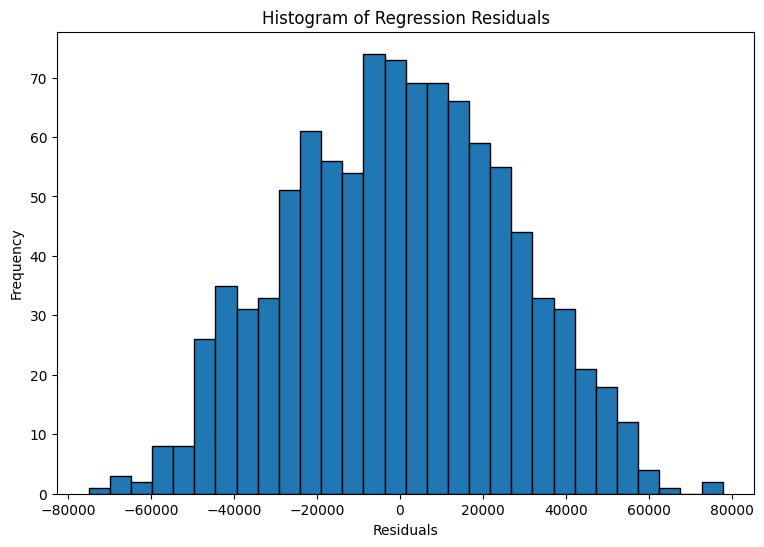

In [34]:
# Histogram of residuals

plt.figure(figsize=(9, 6))
plt.hist(residuals, bins=30, edgecolor="black")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Regression Residuals")
plt.show()

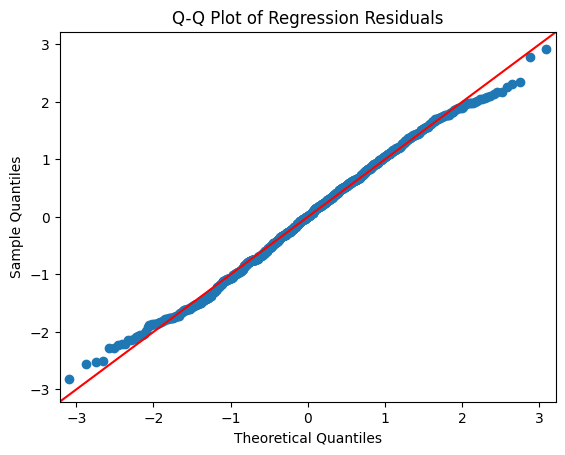

In [35]:
# Q-Q plot

fig = sm.qqplot(residuals, line="45", fit=True)
plt.title("Q-Q Plot of Regression Residuals")
plt.show()

In [36]:
# Shapiro-Wilk normality test

shapiro_stat, shapiro_p = stats.shapiro(residuals)

print(f"Shapiro-Wilk statistic: {shapiro_stat:.4f}")
print(f"Shapiro-Wilk p-value: {shapiro_p:.6f}")

if shapiro_p < 0.05:
    print("\nResult: The test provides evidence against exact normality of the residuals.")
else:
    print("\nResult: The test does not provide strong evidence against normality.")

Shapiro-Wilk statistic: 0.9954
Shapiro-Wilk p-value: 0.003874

Result: The test provides evidence against exact normality of the residuals.


In [37]:
# Durbin-Watson test

dw_stat = durbin_watson(residuals)

print(f"Durbin-Watson statistic: {dw_stat:.4f}")

if dw_stat < 1.5:
    print("The statistic suggests possible positive residual dependence.")
elif dw_stat > 2.5:
    print("The statistic suggests possible negative residual dependence.")
else:
    print("The statistic is in a range generally consistent with limited first-order autocorrelation.")

Durbin-Watson statistic: 2.0465
The statistic is in a range generally consistent with limited first-order autocorrelation.


In [38]:
# Calculate VIF for the predictors

X = preferred_model.model.exog
feature_names = preferred_model.model.exog_names

vif_data = pd.DataFrame()

vif_data["Variable"] = feature_names
vif_data["VIF"] = [
    variance_inflation_factor(X, i)
    for i in range(X.shape[1])
]

display(vif_data.round(4))

,Variable,VIF
0,Intercept,1.0000
1,Square_Footage,1.0104
2,Num_Bathrooms,1.0034
3,Neighborhood_Quality,1.0019
4,Lot_Size,1.0110
5,Garage_Size,1.0017


In [39]:
# Breusch-Pagan test for heteroscedasticity

bp_test = het_breuschpagan(
    preferred_model.resid,
    preferred_model.model.exog
)

bp_labels = [
    "LM Statistic",
    "LM p-value",
    "F Statistic",
    "F p-value"
]

bp_results = pd.Series(bp_test, index=bp_labels)

display(bp_results.to_frame(name="Value").round(6))

,Value
LM Statistic,10.236146
LM p-value,0.068814
F Statistic,2.055991
F p-value,0.068647


In [40]:
# Calculate HC3 heteroscedasticity-robust standard errors

robust_model = preferred_model.get_robustcov_results(cov_type="HC3")

print(robust_model.summary())

                            OLS Regression Results                            
Dep. Variable:            House_Price   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                 1.724e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:03:32   Log-Likelihood:                -11609.
No. Observations:                1000   AIC:                         2.323e+04
Df Residuals:                     994   BIC:                         2.326e+04
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept            -1531.0072 

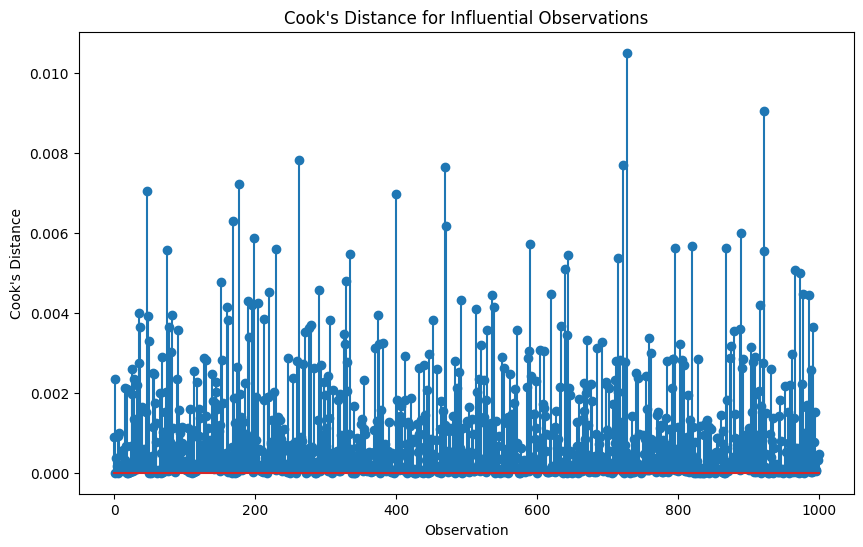

,Observation,Cooks_Distance
728,728,0.010499
922,922,0.009034
262,262,0.007820
722,722,0.007704
470,470,0.007636
177,177,0.007212
47,47,0.007050
400,400,0.006976
169,169,0.006298
471,471,0.006173


In [41]:
# Cook's Distance

influence = preferred_model.get_influence()
cooks_d = influence.cooks_distance[0]

plt.figure(figsize=(10, 6))
plt.stem(range(len(cooks_d)), cooks_d)
plt.xlabel("Observation")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance for Influential Observations")
plt.show()

# Display largest Cook's Distance observations

top_cooks = pd.DataFrame({
    "Observation": np.arange(len(cooks_d)),
    "Cooks_Distance": cooks_d
}).sort_values(
    "Cooks_Distance",
    ascending=False
).head(10)

display(top_cooks)

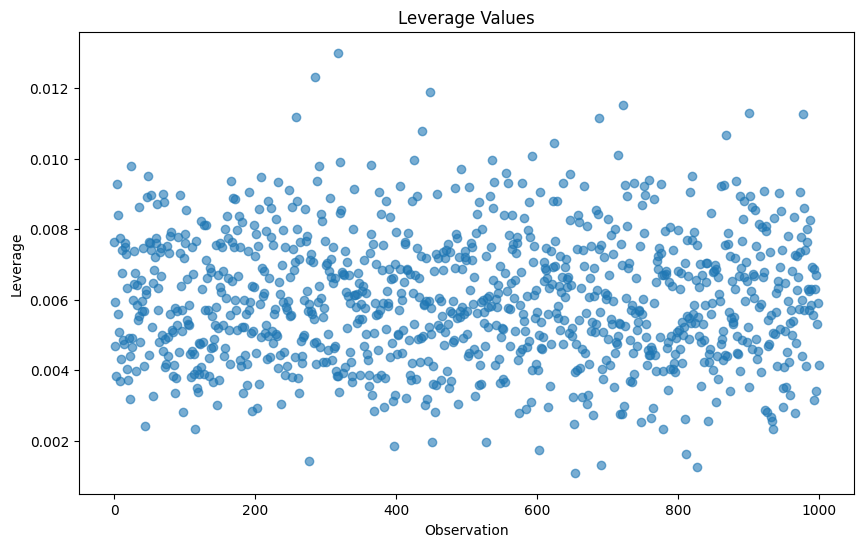

,Observation,Leverage
318,318,0.013008
285,285,0.012325
448,448,0.011885
722,722,0.011516
901,901,0.011299
977,977,0.011258
258,258,0.011190
688,688,0.011168
437,437,0.010777
868,868,0.010684


In [42]:
# Leverage values

leverage = influence.hat_matrix_diag

plt.figure(figsize=(10, 6))
plt.scatter(range(len(leverage)), leverage, alpha=0.6)
plt.xlabel("Observation")
plt.ylabel("Leverage")
plt.title("Leverage Values")
plt.show()

# Display observations with highest leverage

top_leverage = pd.DataFrame({
    "Observation": np.arange(len(leverage)),
    "Leverage": leverage
}).sort_values(
    "Leverage",
    ascending=False
).head(10)

display(top_leverage)

In [43]:
# Create a summary of the main diagnostic statistics

diagnostic_summary = pd.DataFrame({
    "Diagnostic": [
        "Durbin-Watson",
        "Shapiro-Wilk p-value",
        "Breusch-Pagan p-value",
        "Maximum VIF",
        "Maximum Cook's Distance",
        "Maximum Leverage"
    ],
    "Value": [
        dw_stat,
        shapiro_p,
        bp_results["LM p-value"],
        vif_data["VIF"].iloc[1:].max(),
        cooks_d.max(),
        leverage.max()
    ]
})

display(diagnostic_summary.round(4))

,Diagnostic,Value
0,Durbin-Watson,2.0465
1,Shapiro-Wilk p-value,0.0039
2,Breusch-Pagan p-value,0.0688
3,Maximum VIF,1.0110
4,Maximum Cook's Distance,0.0105
5,Maximum Leverage,0.0130


 ### Quadratic Model

In [44]:
# Create a quadratic version of the preferred model

analysis_df["Square_Footage_Squared"] = analysis_df["Square_Footage"] ** 2

quadratic_model = smf.ols(
    "House_Price ~ Square_Footage + Square_Footage_Squared + "
    "Num_Bathrooms + Lot_Size + Neighborhood_Quality + Garage_Size",
    data=analysis_df
).fit()

print(quadratic_model.summary())

                            OLS Regression Results                            
Dep. Variable:            House_Price   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                 1.482e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:11:45   Log-Likelihood:                -11609.
No. Observations:                1000   AIC:                         2.323e+04
Df Residuals:                     993   BIC:                         2.327e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept              -4059

In [45]:
# Compare the original preferred model with the quadratic model

quadratic_residual_se = np.sqrt(
    quadratic_model.ssr / quadratic_model.df_resid
)

refinement_comparison = pd.DataFrame({
    "Model": [
        "Original Preferred Model",
        "Quadratic Model"
    ],
    "R²": [
        preferred_model.rsquared,
        quadratic_model.rsquared
    ],
    "Adjusted R²": [
        preferred_model.rsquared_adj,
        quadratic_model.rsquared_adj
    ],
    "AIC": [
        preferred_model.aic,
        quadratic_model.aic
    ],
    "BIC": [
        preferred_model.bic,
        quadratic_model.bic
    ],
    "Residual SE": [
        np.sqrt(preferred_model.ssr / preferred_model.df_resid),
        quadratic_residual_se
    ]
})

display(refinement_comparison.round(4))

,Model,R²,Adjusted R²,AIC,BIC,Residual SE
0,Original Preferred Model,0.989,0.9889,23230.0708,23259.5173,26718.3504
1,Quadratic Model,0.989,0.9889,23231.5523,23265.9065,26724.8708


In [46]:
# Compare the nested linear and quadratic models

quadratic_anova = anova_lm(
    preferred_model,
    quadratic_model
)

display(quadratic_anova)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,994.0,7.095870e+11,0.0,NaN,NaN,NaN
1,993.0,7.092192e+11,1.0,3.678381e+08,0.515022,0.473142
